# Лабораторная 2 (GPU-вариант): декодерный трансформер на `Tiny Shakespeare`

Решение показывает расширенный перенос авторегрессионного контура на реальный корпус
в режиме `gpu` без резервного CPU-контура.


## Маршрут решения

1. Детерминированная загрузка корпуса и построение словаря.
2. Формирование окон и индексное разбиение.
3. Сборка декодера с причинной маской.
4. Обучение и сравнение с частотным ориентиром.
5. Сравнение с CPU-ориентиром в режиме `gpu`.
6. Детерминированная генерация по фиксированным подсказкам.
7. Диагностика внимания без доступа в будущее.


In [1]:
import ctypes
import importlib.util
import os
import subprocess
import sys
from pathlib import Path

RUNTIME_MODE = os.environ.get("COURSE_RUNTIME_MODE", "local-gpu")
COURSE_REPO_HTTPS_URL = os.environ.get(
    "COURSE_REPO_HTTPS_URL",
    "https://github.com/<org>/<repo>.git",
)
NOTEBOOK_REQUIREMENTS = "themes/04-Autoregression/lab/requirements.txt"


def _prepend_path_env(var_name: str, new_paths: list[Path]) -> None:
    """Добавляет пути в начало переменной окружения с путями.

    Args:
      var_name: Имя переменной окружения (например, `LD_LIBRARY_PATH`).
      new_paths: Пути-кандидаты, которые нужно добавить в начало.

    Returns:
      `None`.

    Raises:
      RuntimeError: Не выбрасывается в штатном режиме.
    """
    existing = os.environ.get(var_name, "")
    cleaned_new = []
    for path in new_paths:
        if path.is_dir():
            cleaned_new.append(str(path))

    if not cleaned_new:
        return

    existing_parts = [part for part in existing.split(":") if part]
    merged = []
    for part in cleaned_new + existing_parts:
        if part not in merged:
            merged.append(part)
    os.environ[var_name] = ":".join(merged)


def _detect_site_packages_dir() -> Path | None:
    """Находит каталог `site-packages` активной виртуальной среды.

    Args:
      Нет.

    Returns:
      Путь к `site-packages` или `None`, если каталог не найден.

    Raises:
      RuntimeError: Не выбрасывается в штатном режиме.
    """
    major, minor = sys.version_info[:2]
    candidate = Path(sys.prefix) / "lib" / f"python{major}.{minor}" / "site-packages"
    if candidate.is_dir():
        return candidate
    return None


def _preload_cuda_runtime_libraries(site_packages: Path) -> dict:
    """Предзагружает CUDA-библиотеки в текущий процесс до импорта TensorFlow.

    Args:
      site_packages: Каталог `site-packages` активной виртуальной среды.

    Returns:
      Сводка со списками успешно загруженных, отсутствующих и проблемных библиотек.

    Raises:
      RuntimeError: Не выбрасывается в штатном режиме.
    """
    nvidia_root = site_packages / "nvidia"
    library_specs = [
        ("cuda_runtime", "libcudart.so.12"),
        ("cublas", "libcublas.so.12"),
        ("cublas", "libcublasLt.so.12"),
        ("cudnn", "libcudnn.so.9"),
        ("cufft", "libcufft.so.11"),
        ("curand", "libcurand.so.10"),
        ("cusolver", "libcusolver.so.11"),
        ("cusparse", "libcusparse.so.12"),
        ("nccl", "libnccl.so.2"),
        ("nvjitlink", "libnvJitLink.so.12"),
    ]

    loaded = []
    missing = []
    failed = []

    for subdir, library_name in library_specs:
        library_path = nvidia_root / subdir / "lib" / library_name
        if not library_path.is_file():
            missing.append(str(library_path))
            continue
        try:
            ctypes.CDLL(str(library_path), mode=ctypes.RTLD_GLOBAL)
            loaded.append(str(library_path))
        except OSError as exc:
            failed.append(f"{library_path}: {exc}")

    return {
        "loaded": loaded,
        "missing": missing,
        "failed": failed,
    }


def _configure_local_gpu_runtime_env(runtime_mode: str) -> dict:
    """Готовит переменные окружения для локального запуска TensorFlow на GPU.

    Args:
      runtime_mode: Запрошенный режим выполнения тетради.

    Returns:
      Словарь с краткой сводкой применённой настройки путей.

    Raises:
      RuntimeError: Не выбрасывается в штатном режиме.
    """
    if runtime_mode != "local-gpu":
        return {
            "applied": False,
            "reason": "runtime_mode != local-gpu",
        }

    site_packages = _detect_site_packages_dir()
    if site_packages is None:
        return {
            "applied": False,
            "reason": "site-packages not found",
        }

    tensorflow_dir = site_packages / "tensorflow"
    nvidia_root = site_packages / "nvidia"
    nvidia_lib_dirs = sorted(path for path in nvidia_root.glob("*/lib") if path.is_dir())
    _prepend_path_env("LD_LIBRARY_PATH", [tensorflow_dir, *nvidia_lib_dirs])

    nvcc_bin = nvidia_root / "cuda_nvcc" / "bin"
    _prepend_path_env("PATH", [nvcc_bin])

    preload_report = _preload_cuda_runtime_libraries(site_packages)

    return {
        "applied": True,
        "tensorflow_dir": str(tensorflow_dir),
        "nvidia_lib_dirs": [str(path) for path in nvidia_lib_dirs],
        "nvcc_bin": str(nvcc_bin),
        "preload_report": preload_report,
    }


gpu_env_info = _configure_local_gpu_runtime_env(RUNTIME_MODE)
print("gpu_env_info:", gpu_env_info)


def _detect_notebook_platform():
    """Определяет тип среды выполнения текущей тетради.

    Args:
      Нет.

    Returns:
      Строка из множества `{'local', 'colab', 'kaggle'}`.

    Raises:
      RuntimeError: Не выбрасывается в штатном режиме.
    """
    if os.environ.get("KAGGLE_KERNEL_RUN_TYPE") or Path("/kaggle").exists():
        return "kaggle"
    if os.environ.get("COLAB_RELEASE_TAG") or "google.colab" in sys.modules:
        return "colab"
    return "local"


def _looks_like_repo_root(path: Path) -> bool:
    """Проверяет, похож ли путь на корень учебного репозитория.

    Args:
      path: Проверяемый путь.

    Returns:
      `True`, если обнаружены ключевые признаки корня репозитория.

    Raises:
      RuntimeError: Не выбрасывается в штатном режиме.
    """
    return (
        path.is_dir()
        and (path / "themes").is_dir()
        and (path / "course_runtime.py").is_file()
    )


def _canonical_cloud_repo_root(platform: str) -> Path:
    """Возвращает стандартный путь клонирования для облачной платформы.

    Args:
      platform: Имя платформы (`'colab'` или `'kaggle'`).

    Returns:
      Абсолютный путь каталога репозитория.

    Raises:
      ValueError: Если передано неподдерживаемое имя платформы.
    """
    if platform == "colab":
        return Path("/content/students-AI_math_essentials")
    if platform == "kaggle":
        return Path("/kaggle/working/students-AI_math_essentials")
    raise ValueError(f"Unexpected cloud platform: {platform}")


def _is_placeholder_repo_url(repo_url: str) -> bool:
    """Проверяет, остался ли в настройке шаблонный URL репозитория.

    Args:
      repo_url: Проверяемый URL репозитория.

    Returns:
      `True`, если URL имеет вид шаблона-заглушки.

    Raises:
      RuntimeError: Не выбрасывается в штатном режиме.
    """
    return repo_url.strip() == "https://github.com/<org>/<repo>.git"


def _find_repo_root_from_cwd():
    """Ищет корень курса, поднимаясь от текущего каталога вверх.

    Args:
      Нет.

    Returns:
      Объект `Path` корня репозитория или `None`, если путь не найден.

    Raises:
      RuntimeError: Не выбрасывается в штатном режиме.
    """
    for candidate in (Path.cwd(), *Path.cwd().parents):
        if _looks_like_repo_root(candidate):
            return candidate
    return None


def _ensure_course_runtime_importable(runtime_mode: str, repo_url: str) -> None:
    """Обеспечивает доступность модуля `course_runtime` для текущей среды.

    Args:
      runtime_mode: Режим запуска тетради.
      repo_url: URL репозитория курса для облачной автозагрузки.

    Returns:
      `None`.

    Raises:
      ModuleNotFoundError: Если локальный запуск выполнен вне корректного корня репозитория.
      RuntimeError: Если в облаке отсутствует валидный URL репозитория или каталог повреждён.
      subprocess.CalledProcessError: Если команда `git clone` завершается с ошибкой.
    """
    if importlib.util.find_spec("course_runtime") is not None:
        return

    local_repo_root = _find_repo_root_from_cwd()
    if local_repo_root is not None:
        if str(local_repo_root) not in sys.path:
            sys.path.insert(0, str(local_repo_root))
        return

    platform = _detect_notebook_platform()
    if platform == "local":
        raise ModuleNotFoundError(
            "Не удалось импортировать course_runtime.py. Для локального запуска "
            "открывайте репозиторий через `.venv/bin/jupyter notebook` из корня проекта."
        )

    repo_root = _canonical_cloud_repo_root(platform)
    if not _looks_like_repo_root(repo_root):
        if _is_placeholder_repo_url(repo_url):
            raise RuntimeError(
                "Для cloud auto-bootstrap нужен публичный HTTPS URL курса. "
                "Замените COURSE_REPO_HTTPS_URL на реальный адрес репозитория."
            )
        repo_root.parent.mkdir(parents=True, exist_ok=True)
        if repo_root.exists() and any(repo_root.iterdir()):
            raise RuntimeError(
                f"Каталог {repo_root} уже существует, но не выглядит как корень курса. "
                "Очистите runtime или используйте новый notebook session."
            )
        print(f"Bootstrapping course repository into {repo_root} ...")
        subprocess.run(["git", "clone", repo_url, str(repo_root)], check=True)

    if str(repo_root) not in sys.path:
        sys.path.insert(0, str(repo_root))


_ensure_course_runtime_importable(RUNTIME_MODE, COURSE_REPO_HTTPS_URL)

from course_runtime import setup_notebook_runtime

runtime_info = setup_notebook_runtime(
    runtime_mode=RUNTIME_MODE,
    course_repo_https_url=COURSE_REPO_HTTPS_URL,
    notebook_requirements=NOTEBOOK_REQUIREMENTS,
)
runtime_info.as_dict()


gpu_env_info: {'applied': True, 'tensorflow_dir': '/home/sorcerer/Projects/edu-ai-math-essentials/.venv/lib/python3.12/site-packages/tensorflow', 'nvidia_lib_dirs': ['/home/sorcerer/Projects/edu-ai-math-essentials/.venv/lib/python3.12/site-packages/nvidia/cublas/lib', '/home/sorcerer/Projects/edu-ai-math-essentials/.venv/lib/python3.12/site-packages/nvidia/cuda_cupti/lib', '/home/sorcerer/Projects/edu-ai-math-essentials/.venv/lib/python3.12/site-packages/nvidia/cuda_nvrtc/lib', '/home/sorcerer/Projects/edu-ai-math-essentials/.venv/lib/python3.12/site-packages/nvidia/cuda_runtime/lib', '/home/sorcerer/Projects/edu-ai-math-essentials/.venv/lib/python3.12/site-packages/nvidia/cudnn/lib', '/home/sorcerer/Projects/edu-ai-math-essentials/.venv/lib/python3.12/site-packages/nvidia/cufft/lib', '/home/sorcerer/Projects/edu-ai-math-essentials/.venv/lib/python3.12/site-packages/nvidia/curand/lib', '/home/sorcerer/Projects/edu-ai-math-essentials/.venv/lib/python3.12/site-packages/nvidia/cusolver/li

I0000 00:00:1774994395.599587 2795113 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1774994395.644410 2795113 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI AVX_VNNI_INT8 AVX_NE_CONVERT FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


I0000 00:00:1774994397.288115 2795113 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


Runtime summary:
- requested mode: local-gpu
- effective mode: local-gpu
- detected platform: local
- repo root: /home/sorcerer/Projects/edu-ai-math-essentials
- visible GPUs: ['/device:GPU:0']
- compute device: GPU
If you change RUNTIME_MODE, use 'Restart & Run All' before continuing.


W0000 00:00:1774994398.778171 2795113 gpu_device.cc:2459] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0a. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.
W0000 00:00:1774994398.785075 2795113 gpu_device.cc:2459] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0a. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.
I0000 00:00:1774994398.964462 2795113 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 7484 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 5070 Ti Laptop GPU, pci bus id: 0000:02:00.0, compute capability: 12.0a


{'requested_mode': 'local-gpu',
 'effective_mode': 'local-gpu',
 'platform': 'local',
 'repo_root': '/home/sorcerer/Projects/edu-ai-math-essentials',
 'visible_gpus': ('/device:GPU:0',),
 'compute_device': 'GPU',
 'cloud_bootstrap': False,
 'dependencies_installed': False}

## Константы GPU-варианта

Перед запуском установите `COURSE_RUNTIME_MODE=local-gpu`.


In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from pathlib import Path

SEED = 29
PAD_ID = 0
CHECK_GEN_STEPS = 16
PROMPT_COUNT = 20
CPU_REFERENCE_PERPLEXITY = 7.64

GPU_60M_PROFILE = {
    'chars': 900_000,
    'context': 128,
    'stride': 1,
    'batch_size': 128,
    'embed_dim': 192,
    'num_heads': 6,
    'ff_dim': 384,
    'eval_every_steps': 1200,
    'validation_steps': 64,
    'max_eval_rounds': 180,
    'early_stopping_patience': 16,
    'early_stopping_min_delta': 1e-4,
    'early_stopping_probe_floor': 18,
    'min_minutes_before_early_stop': 45,
    'max_training_minutes': 60,
    'min_minutes_before_generation_stop': 20,
    'generation_stop_patience': 2,
    'generation_probe_every': 4,
    'learning_rate': 1e-3,
    'gen_match_ratio': 0.18,
    'gen_threshold': 19,
    'gen_mean_threshold': 0.25,
}

GPU_60M_PROFILE_BOOST = {
    **GPU_60M_PROFILE,
    'eval_every_steps': 1500,
    'validation_steps': 64,
    'generation_probe_every': 3,
    'early_stopping_patience': 20,
    'learning_rate': 8e-4,
}

GPU_PROFILE_MAP = {
    'gpu_60m': GPU_60M_PROFILE,
    'gpu_60m_boost': GPU_60M_PROFILE_BOOST,
}


def gpu_preflight(runtime_info):
    """Проверяет готовность локального GPU-контура перед длинным обучением.

    Args:
      runtime_info: Результат `setup_notebook_runtime(...)` с полем `effective_mode`.

    Returns:
      Словарь с краткой сводкой по обнаруженным GPU и версии TensorFlow.

    Raises:
      RuntimeError: Если режим запуска не `local-gpu`, GPU не виден,
        либо GPU-ядра нестабильны на реальной короткой нагрузке.
    """
    effective_mode = getattr(runtime_info, 'effective_mode', '')
    print('effective_mode:', effective_mode)
    if effective_mode != 'local-gpu':
        raise RuntimeError(
            'GPU-вариант ЛР02 должен запускаться только в режиме local-gpu. '
            'Установите COURSE_RUNTIME_MODE=local-gpu и перезапустите ядро.'
        )

    try:
        nvidia_report = subprocess.run(
            ['nvidia-smi', '-L'],
            check=True,
            capture_output=True,
            text=True,
        )
        lines = [line for line in nvidia_report.stdout.strip().splitlines() if line.strip()]
        print('nvidia-smi -L (первые строки):')
        for line in lines[:3]:
            print('  ', line)
    except Exception as exc:
        raise RuntimeError(
            'GPU не виден (setup): команда nvidia-smi недоступна или вернула ошибку. '
            'Используйте уже подготовленную среду из '
            'themes/00-Foundations/guides/05_local_tensorflow_gpu_notebooks.md '
            'и не переустанавливайте ОС внутри ЛР.'
        ) from exc

    print('TensorFlow version:', tf.__version__)
    print('TensorFlow built with CUDA:', tf.test.is_built_with_cuda())
    build_info = tf.sysconfig.get_build_info()
    print('TensorFlow build cuda_version:', build_info.get('cuda_version', 'unknown'))
    print('TensorFlow build cudnn_version:', build_info.get('cudnn_version', 'unknown'))

    physical_gpus = tf.config.list_physical_devices('GPU')
    logical_gpus = tf.config.list_logical_devices('GPU')
    print('Physical GPUs:', [device.name for device in physical_gpus])
    print('Logical GPUs :', [device.name for device in logical_gpus])

    if len(physical_gpus) == 0 or len(logical_gpus) == 0:
        raise RuntimeError(
            'GPU не виден (setup): TensorFlow не зарегистрировал GPU-устройства. '
            'Проверьте окружение по guide 05/06 в themes/00-Foundations.'
        )

    try:
        # Проверка 1: базовая матричная операция на /GPU:0.
        with tf.device('/GPU:0'):
            lhs = tf.random.normal((128, 128), dtype=tf.float32)
            rhs = tf.random.normal((128, 128), dtype=tf.float32)
            product = tf.matmul(lhs, rhs)
            _ = float(tf.reduce_mean(product).numpy())

        # Проверка 2: короткий notebook-like шаг обучения Keras на /GPU:0.
        features = np.random.normal(size=(32, 8)).astype('float32')
        targets = np.random.normal(size=(32, 1)).astype('float32')
        with tf.device('/GPU:0'):
            smoke_model = keras.Sequential(
                [
                    layers.Input(shape=(8,)),
                    layers.Dense(16, activation='relu'),
                    layers.Dense(1),
                ],
                name='gpu_smoke_model',
            )
            smoke_model.compile(
                optimizer=keras.optimizers.Adam(1e-3),
                loss='mse',
            )
            smoke_model.train_on_batch(features, targets)
    except Exception as exc:
        raise RuntimeError(
            'GPU виден, но kernels падают (compatibility). Это не ошибка кода ЛР. '
            'См. themes/00-Foundations/guides/07_tensorflow_blackwell_local_gpu_case_study.md. '
            f'Исходная ошибка: {type(exc).__name__}: {exc}'
        ) from exc

    print('gpu_preflight(): PASSED')
    return {
        'tensorflow_version': tf.__version__,
        'cuda_version': build_info.get('cuda_version', 'unknown'),
        'cudnn_version': build_info.get('cudnn_version', 'unknown'),
        'physical_gpus': [device.name for device in physical_gpus],
        'logical_gpus': [device.name for device in logical_gpus],
    }


RUN_MODE = 'gpu'
selected_profile_name = os.environ.get('GPU_PROFILE_NAME', 'gpu_60m').strip().lower()
if selected_profile_name not in GPU_PROFILE_MAP:
    raise ValueError(
        f"Неизвестный профиль GPU: {selected_profile_name}. "
        f"Допустимые значения: {sorted(GPU_PROFILE_MAP)}"
    )

cfg = dict(GPU_PROFILE_MAP[selected_profile_name])
cfg['max_training_minutes'] = float(
    os.environ.get('GPU_TRAINING_BUDGET_MINUTES', cfg['max_training_minutes'])
)
cfg['warmup_steps'] = int(os.environ.get('GPU_WARMUP_STEPS', '2'))
cfg['warmup_probe_steps'] = int(os.environ.get('GPU_WARMUP_PROBE_STEPS', '2'))

if cfg['max_training_minutes'] <= 0:
    raise ValueError('GPU_TRAINING_BUDGET_MINUTES должен быть положительным числом.')
if cfg['warmup_steps'] < 1:
    raise ValueError('GPU_WARMUP_STEPS должен быть целым числом >= 1.')
if cfg['warmup_probe_steps'] < 1:
    raise ValueError('GPU_WARMUP_PROBE_STEPS должен быть целым числом >= 1.')

plt.style.use('default')
keras.utils.set_random_seed(SEED)

preflight_info = gpu_preflight(runtime_info)
print('Режим выполнения:', RUN_MODE)
print('Профиль GPU:', selected_profile_name)
print('Измеряемый бюджет обучения (мин):', cfg['max_training_minutes'])


effective_mode: local-gpu
nvidia-smi -L (первые строки):
   GPU 0: NVIDIA GeForce RTX 5070 Ti Laptop GPU (UUID: GPU-8e82fa94-16eb-58fe-a887-26ffdf73f07d)
TensorFlow version: 2.21.0
TensorFlow built with CUDA: True
TensorFlow build cuda_version: 12.5.1
TensorFlow build cudnn_version: 9
Physical GPUs: ['/physical_device:GPU:0']
Logical GPUs : ['/device:GPU:0']


I0000 00:00:1774994400.081117 2795113 service.cc:153] XLA service 0x3dd4f970 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1774994400.081133 2795113 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 5070 Ti Laptop GPU, Compute Capability 12.0a (Driver: 13.0.0; Runtime: 12.5.0; Toolkit: 12.5.0; DNN: 9.3.0)
I0000 00:00:1774994400.092712 2795113 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1774994400.177489 2795113 cuda_dnn.cc:461] Loaded cuDNN version 90300
I0000 00:00:1774994400.183403 2795113 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_775__XlaMustCompile_true_config_proto_6399381512057327405_executor_type_11160318154034397263_.5


gpu_preflight(): PASSED
Режим выполнения: gpu
Профиль GPU: gpu_60m
Измеряемый бюджет обучения (мин): 60.0


I0000 00:00:1774994400.947062 2795113 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


## Теоретический ориентир

Перплексия рассчитывается как `exp(loss)` и сравнивается с частотным базовым ориентиром,
построенным на обучающей части корпуса.

В режиме `gpu` дополнительно проверяется улучшение относительно
фиксированного CPU-ориентира `CPU_REFERENCE_PERPLEXITY`.


## Шаг 1: загрузка корпуса и построение словаря


In [3]:
def load_tiny_shakespeare(profile_cfg):
    """Загружает корпус и строит детерминированное символьное кодирование.

    Args:
      profile_cfg: Словарь параметров выбранного профиля.

    Returns:
      Кортеж `(text, encoded_ids, vocab, char_to_id, id_to_char)`.

    Raises:
      ValueError: Если выбранный профиль задаёт слишком короткий фрагмент текста.
    """
    path = tf.keras.utils.get_file(
        'tiny_shakespeare.txt',
        'https://storage.googleapis.com/download.tensorflow.org/data/shakespeare.txt',
    )
    full_text = Path(path).read_text(encoding='utf-8')
    text = full_text[: profile_cfg['chars']]

    min_len = profile_cfg['context'] + CHECK_GEN_STEPS + 2
    if len(text) < min_len:
        raise ValueError('Срез корпуса слишком короткий для выбранного профиля.')

    chars = sorted(set(text))
    vocab = ['<PAD>', *chars]
    char_to_id = {ch: idx for idx, ch in enumerate(vocab)}
    id_to_char = {idx: ch for ch, idx in char_to_id.items()}

    encoded_ids = np.asarray([char_to_id[ch] for ch in text], dtype=np.int32)
    return text, encoded_ids, vocab, char_to_id, id_to_char


text, encoded_ids, vocab, char_to_id, id_to_char = load_tiny_shakespeare(cfg)
VOCAB_SIZE = len(vocab)
print('Режим выполнения:', RUN_MODE)
print('Длина текста:', len(text))
print('Размер словаря:', VOCAB_SIZE)


Режим выполнения: gpu
Длина текста: 900000
Размер словаря: 66


In [4]:
assert len(text) == cfg['chars']
assert encoded_ids.dtype == np.int32
assert vocab[PAD_ID] == '<PAD>'

text_b, ids_b, _, _, _ = load_tiny_shakespeare(cfg)
assert np.array_equal(encoded_ids[:1000], ids_b[:1000])
print('Детерминизм загрузки подтверждён.')


Детерминизм загрузки подтверждён.


## Шаг 2: окна и индексное разбиение


In [5]:
def build_windows(encoded_stream, context_len, stride):
    """Строит обучающие окна фиксированной длины.

    Args:
      encoded_stream: Одномерный массив кодов символов.
      context_len: Длина входного контекста.
      stride: Шаг между соседними окнами.

    Returns:
      Кортеж `(X, Y, starts)`.

    Raises:
      ValueError: Если поток слишком короткий для построения хотя бы одного окна.
    """
    max_start = len(encoded_stream) - (context_len + 1)
    if max_start < 0:
        raise ValueError('Недостаточно символов для построения окон.')

    starts = np.arange(0, max_start + 1, stride, dtype=np.int32)
    windows = np.stack([encoded_stream[s:s + context_len + 1] for s in starts], axis=0)
    X = windows[:, :-1]
    Y = windows[:, 1:]
    return X.astype(np.int32), Y.astype(np.int32), starts


X_all, y_all, starts_all = build_windows(encoded_ids, cfg['context'], cfg['stride'])

total = len(X_all)
train_end = int(total * 0.8)
val_end = int(total * 0.9)

X_train, y_train, starts_train = X_all[:train_end], y_all[:train_end], starts_all[:train_end]
X_val, y_val, starts_val = X_all[train_end:val_end], y_all[train_end:val_end], starts_all[train_end:val_end]
X_test, y_test, starts_test = X_all[val_end:], y_all[val_end:], starts_all[val_end:]

train_ds = tf.data.Dataset.from_tensor_slices((X_train, y_train)).batch(cfg['batch_size']).prefetch(tf.data.AUTOTUNE)
val_ds = tf.data.Dataset.from_tensor_slices((X_val, y_val)).batch(cfg['batch_size']).prefetch(tf.data.AUTOTUNE)
test_ds = tf.data.Dataset.from_tensor_slices((X_test, y_test)).batch(cfg['batch_size']).prefetch(tf.data.AUTOTUNE)


In [6]:
assert X_train.shape[1] == cfg['context']
assert y_train.shape == X_train.shape
assert starts_train.ndim == 1
assert np.array_equal(X_train[0, 1:], y_train[0, :-1])
print('Окон train/val/test:', len(X_train), len(X_val), len(X_test))


Окон train/val/test: 719897 89987 89988


## Шаг 3: декодерный блок с причинной маской


In [7]:
def build_causal_mask(seq_len):
    """Строит нижнетреугольную причинную маску.

    Args:
      seq_len: Длина последовательности.

    Returns:
      Булев тензор формы `(seq_len, seq_len)`.

    Raises:
      tf.errors.InvalidArgumentError: Если `seq_len` не является положительным.
    """
    seq_len = tf.cast(seq_len, tf.int32)
    tf.debugging.assert_positive(seq_len, message='seq_len должен быть положительным.')
    shape = tf.stack([seq_len, seq_len])
    return tf.linalg.band_part(tf.ones(shape, dtype=tf.bool), -1, 0)


class TokenAndPositionEmbedding(layers.Layer):
    """Складывает токенные и позиционные векторы.

    Args:
      maxlen: Максимальная длина контекста.
      vocab_size: Размер словаря.
      embed_dim: Размер скрытого представления.
      **kwargs: Дополнительные аргументы базового слоя.

    Returns:
      Экземпляр слоя встраивания.

    Raises:
      ValueError: Если `embed_dim` меньше 1.
    """

    def __init__(self, maxlen, vocab_size, embed_dim, **kwargs):
        """Инициализирует слой токенного и позиционного встраивания.

        Args:
          maxlen: Максимальная длина контекста.
          vocab_size: Размер словаря токенов.
          embed_dim: Размерность векторного представления.
          **kwargs: Дополнительные аргументы базового слоя Keras.

        Returns:
          None.

        Raises:
          ValueError: Если `embed_dim` меньше 1.
        """
        super().__init__(**kwargs)
        if embed_dim < 1:
            raise ValueError('embed_dim должен быть положительным.')
        self.token_embedding = layers.Embedding(vocab_size, embed_dim, mask_zero=True)
        self.position_embedding = layers.Embedding(maxlen, embed_dim)

    def call(self, inputs):
        """Суммирует токенные и позиционные векторы.

        Args:
          inputs: Матрица идентификаторов формы `(batch, time)`.

        Returns:
          Тензор формы `(batch, time, embed_dim)`.

        Raises:
          RuntimeError: Не выбрасывается в штатном режиме.
        """
        positions = tf.range(start=0, limit=tf.shape(inputs)[-1], delta=1)
        token_vectors = self.token_embedding(inputs)
        position_vectors = self.position_embedding(positions)
        return token_vectors + position_vectors

    def compute_mask(self, inputs, mask=None):
        """Пробрасывает маску непустых токенов.

        Args:
          inputs: Матрица токенов.
          mask: Входная маска.

        Returns:
          Булева маска формы `(batch, time)`.

        Raises:
          RuntimeError: Не выбрасывается в штатном режиме.
        """
        return self.token_embedding.compute_mask(inputs)


class CausalDecoderBlock(layers.Layer):
    """Минимальный декодерный блок с причинной маской.

    Args:
      embed_dim: Размер скрытого представления.
      num_heads: Число голов внимания.
      ff_dim: Размер скрытого слоя позиционно-независимой сети.
      rate: Доля прореживания.
      **kwargs: Дополнительные аргументы базового слоя.

    Returns:
      Экземпляр декодерного блока.

    Raises:
      ValueError: Если `embed_dim` не делится на `num_heads`.
    """

    def __init__(self, embed_dim, num_heads, ff_dim, rate=0.1, **kwargs):
        """Создаёт внутренние слои декодерного блока.

        Args:
          embed_dim: Размерность входных признаков.
          num_heads: Число голов внимания.
          ff_dim: Размер скрытого слоя позициионно-независимой сети.
          rate: Доля выключаемых нейронов в прореживании.
          **kwargs: Дополнительные аргументы базового слоя Keras.

        Returns:
          None.

        Raises:
          ValueError: Если `embed_dim` не делится на `num_heads`.
        """
        super().__init__(**kwargs)
        if embed_dim % num_heads != 0:
            raise ValueError('embed_dim должен делиться на num_heads без остатка.')
        self.self_attention = layers.MultiHeadAttention(
            num_heads=num_heads,
            key_dim=embed_dim // num_heads,
            dropout=rate,
        )
        self.ffn = keras.Sequential(
            [
                layers.Dense(ff_dim, activation='relu'),
                layers.Dense(embed_dim),
            ]
        )
        self.norm_1 = layers.LayerNormalization(epsilon=1e-6)
        self.norm_2 = layers.LayerNormalization(epsilon=1e-6)
        self.dropout_1 = layers.Dropout(rate)
        self.dropout_2 = layers.Dropout(rate)

    def call(self, inputs, padding_mask=None, training=None, return_attention_scores=False):
        """Прогоняет вход через маскированное самовнимание и FFN.

        Args:
          inputs: Тензор формы `(batch, time, embed_dim)`.
          padding_mask: Булева маска формы `(batch, time)`.
          training: Признак режима обучения.
          return_attention_scores: Нужно ли вернуть веса внимания.

        Returns:
          Либо выходной тензор, либо кортеж `(выход, attention_scores)`.

        Raises:
          RuntimeError: Не выбрасывается в штатном режиме.
        """
        seq_len = tf.shape(inputs)[1]
        causal_mask = build_causal_mask(seq_len)[tf.newaxis, :, :]

        if padding_mask is None:
            attention_mask = causal_mask
        else:
            # Ключи и запросы одновременно ограничиваются непустыми позициями.
            key_mask = tf.cast(padding_mask[:, tf.newaxis, :], tf.bool)
            query_mask = tf.cast(padding_mask[:, :, tf.newaxis], tf.bool)
            attention_mask = causal_mask & key_mask & query_mask

        attention_output, attention_scores = self.self_attention(
            query=inputs,
            value=inputs,
            key=inputs,
            attention_mask=attention_mask,
            return_attention_scores=True,
            training=training,
        )

        x = self.norm_1(inputs + self.dropout_1(attention_output, training=training))
        y = self.ffn(x)
        output = self.norm_2(x + self.dropout_2(y, training=training))

        if return_attention_scores:
            return output, attention_scores
        return output

    def compute_mask(self, inputs, mask=None):
        """Отключает автоматическое пробрасывание маски в выход блока.

        Args:
          inputs: Входной тензор признаков.
          mask: Маска, пришедшая от предыдущего слоя.

        Returns:
          `None`, чтобы маскирование контролировалось явно в функции потерь.

        Raises:
          RuntimeError: Не выбрасывается в штатном режиме.
        """
        return None


def masked_sparse_crossentropy(y_true, y_pred):
    """Считает перекрёстную энтропию по непустым позициям.

    Args:
      y_true: Истинные токены.
      y_pred: Предсказанные распределения.

    Returns:
      Среднее значение функции потерь.

    Raises:
      RuntimeError: Не выбрасывается в штатном режиме.
    """
    per_token = tf.keras.losses.sparse_categorical_crossentropy(y_true, y_pred)
    mask = tf.cast(tf.not_equal(y_true, PAD_ID), tf.float32)
    return tf.reduce_sum(per_token * mask) / tf.reduce_sum(mask)


def masked_token_accuracy(y_true, y_pred):
    """Считает токенную точность по непустым позициям.

    Args:
      y_true: Истинные токены.
      y_pred: Предсказанные распределения.

    Returns:
      Доля верных токенов.

    Raises:
      RuntimeError: Не выбрасывается в штатном режиме.
    """
    pred = tf.argmax(y_pred, axis=-1, output_type=y_true.dtype)
    correct = tf.cast(tf.equal(y_true, pred), tf.float32)
    mask = tf.cast(tf.not_equal(y_true, PAD_ID), tf.float32)
    return tf.reduce_sum(correct * mask) / tf.reduce_sum(mask)


def perplexity_from_loss(loss_value):
    """Преобразует значение функции потерь в перплексию.

    Args:
      loss_value: Средняя перекрёстная энтропия.

    Returns:
      Значение перплексии.

    Raises:
      RuntimeError: Не выбрасывается в штатном режиме.
    """
    return float(np.exp(loss_value))


def frequency_baseline_perplexity(y_train_data, y_test_data, vocab_size, pad_id=PAD_ID):
    """Считает частотный базовый ориентир перплексии.

    Args:
      y_train_data: Целевые токены обучающей выборки.
      y_test_data: Целевые токены тестовой выборки.
      vocab_size: Размер словаря.
      pad_id: Идентификатор дополнения.

    Returns:
      Значение базовой перплексии.

    Raises:
      ValueError: Если в данных нет полезных токенов.
    """
    train_tokens = y_train_data[y_train_data != pad_id].reshape(-1)
    test_tokens = y_test_data[y_test_data != pad_id].reshape(-1)
    if len(train_tokens) == 0 or len(test_tokens) == 0:
        raise ValueError('Для базового ориентира нужны непустые токены.')

    counts = np.bincount(train_tokens, minlength=vocab_size).astype(np.float64)
    probs = counts / counts.sum()
    probs = np.maximum(probs, 1e-12)

    nll = -np.mean(np.log(probs[test_tokens]))
    return float(np.exp(nll))


## Шаг 4: сборка и обучение модели

Обязательный контракт GPU-варианта:
- лимит времени `cfg['max_training_minutes']` минут (по умолчанию `90`);
- валидация каждые `cfg['eval_every_steps']` шагов;
- ранняя остановка по `val_loss`;
- целевая генерация: не ниже `19/20` фиксированных подсказок.


In [8]:
import time

keras.utils.set_random_seed(SEED)
# Включаем детерминизм TensorFlow-операций для воспроизводимости GPU-маршрута.
tf.config.experimental.enable_op_determinism()

token_ids = keras.Input(shape=(cfg['context'],), dtype='int32', name='token_ids')
padding_mask = layers.Lambda(lambda t: tf.not_equal(t, PAD_ID), name='padding_mask')(token_ids)

embedding_layer = TokenAndPositionEmbedding(
    cfg['context'],
    VOCAB_SIZE,
    cfg['embed_dim'],
    name='token_position_embedding',
)
decoder_layer = CausalDecoderBlock(
    cfg['embed_dim'],
    cfg['num_heads'],
    cfg['ff_dim'],
    rate=0.1,
    name='causal_decoder',
)

x = embedding_layer(token_ids)
x = decoder_layer(x, padding_mask=padding_mask)
y_pred = layers.Dense(VOCAB_SIZE, activation='softmax', name='next_token_distribution')(x)

model = keras.Model(token_ids, y_pred, name='tiny_shakespeare_decoder')
model.compile(
    optimizer=keras.optimizers.Adam(cfg['learning_rate']),
    loss=masked_sparse_crossentropy,
    metrics=[masked_token_accuracy],
)


def build_probe_pairs(encoded_stream, start_indices, context_len, continuation_len, n_prompts):
    """Готовит фиксированные пары подсказка-цель для generation-probe.

    Args:
      encoded_stream: Полный поток кодов корпуса.
      start_indices: Стартовые индексы окон валидационной части.
      context_len: Длина контекста модели.
      continuation_len: Длина проверяемого продолжения.
      n_prompts: Количество подсказок для проверки.

    Returns:
      Список пар `(prompt_ids, target_ids)` длины `n_prompts`.

    Raises:
      ValueError: Если доступных окон недостаточно.
    """
    valid_starts = [
        int(start) for start in start_indices
        if int(start) + context_len + continuation_len <= len(encoded_stream)
    ]
    if len(valid_starts) < n_prompts:
        raise ValueError('Недостаточно окон для generation-probe.')

    selected = np.linspace(0, len(valid_starts) - 1, n_prompts, dtype=int)
    pairs = []
    for idx in selected:
        start = valid_starts[int(idx)]
        prompt = encoded_stream[start:start + context_len]
        target = encoded_stream[start + context_len:start + context_len + continuation_len]
        pairs.append((prompt.tolist(), target.tolist()))
    return pairs


def next_token_distribution(model_obj, history_ids, context_len):
    """Возвращает распределение следующего токена через прямой вызов модели.

    Args:
      model_obj: Экземпляр Keras-модели.
      history_ids: История токенов, формирующая контекст.
      context_len: Максимальная длина контекста модели.

    Returns:
      Массив вероятностей по словарю для следующего токена.

    Raises:
      ValueError: Если `history_ids` пуст.
    """
    if len(history_ids) == 0:
        raise ValueError('История токенов не может быть пустой.')

    model_input = np.full((1, context_len), PAD_ID, dtype=np.int32)
    clipped = history_ids[-context_len:]
    model_input[0, -len(clipped):] = clipped
    logits = model_obj(model_input, training=False)
    return logits.numpy()[0, -1]


def controlled_match_ratio(model_obj, prompt_ids, target_ids, context_len):
    """Считает долю совпадений в режиме эталонного контекста (teacher forcing).

    Args:
      model_obj: Обучаемая модель.
      prompt_ids: Начальная подсказка.
      target_ids: Эталонное продолжение фиксированной длины.
      context_len: Длина модельного контекста.

    Returns:
      Доля совпадений токенов на продолжении.

    Raises:
      ValueError: Если подсказка или продолжение пусты.
    """
    if len(prompt_ids) == 0:
        raise ValueError('Подсказка не может быть пустой.')
    if len(target_ids) == 0:
        raise ValueError('Эталонное продолжение не может быть пустым.')

    matches = 0
    history = list(prompt_ids)
    for true_token in target_ids:
        probs = next_token_distribution(model_obj, history, context_len)
        pred_token = int(np.argmax(probs))
        if pred_token == int(true_token):
            matches += 1
        # Добавляем истинный токен, чтобы избежать каскада накопленных ошибок.
        history.append(int(true_token))

    return float(matches / len(target_ids))


def evaluate_generation_probe(model_obj, probe_pairs, context_len, per_prompt_threshold):
    """Оценивает контролируемые продолжения на фиксированном наборе подсказок.

    Args:
      model_obj: Обучаемая модель.
      probe_pairs: Список пар `(prompt_ids, target_ids)`.
      context_len: Длина модельного контекста.
      per_prompt_threshold: Минимальная доля совпадений для успеха одной подсказки.

    Returns:
      Кортеж `(success_count, mean_match_ratio)`.

    Raises:
      ValueError: Если список `probe_pairs` пуст.
    """
    if len(probe_pairs) == 0:
        raise ValueError('Список probe_pairs не может быть пустым.')

    success_count = 0
    match_ratios = []
    for prompt_ids, target_ids in probe_pairs:
        match_ratio = controlled_match_ratio(
            model_obj,
            prompt_ids,
            target_ids,
            context_len=context_len,
        )
        match_ratios.append(match_ratio)
        if match_ratio >= per_prompt_threshold:
            success_count += 1

    mean_match_ratio = float(np.mean(match_ratios)) if match_ratios else 0.0
    return success_count, mean_match_ratio


def run_warmup_phase(
    model_obj,
    train_stream,
    val_stream,
    probe_pairs,
    context_len,
    warmup_steps,
    warmup_probe_steps,
):
    """Выполняет отдельный warm-up для JIT/графов до запуска 60-минутного бюджета.

    Args:
      model_obj: Обучаемая модель.
      train_stream: Бесконечный поток обучающих батчей.
      val_stream: Бесконечный поток валидационных батчей.
      probe_pairs: Фиксированные пары для generation-probe.
      context_len: Длина модельного контекста.
      warmup_steps: Количество коротких train_on_batch шагов.
      warmup_probe_steps: Длина короткой проверки в warm-up.

    Returns:
      Словарь с продолжительностью warm-up и числом выполненных шагов.

    Raises:
      ValueError: Если `warmup_steps` или `warmup_probe_steps` меньше 1.
    """
    if warmup_steps < 1:
        raise ValueError('warmup_steps должен быть >= 1.')
    if warmup_probe_steps < 1:
        raise ValueError('warmup_probe_steps должен быть >= 1.')

    warmup_start = time.perf_counter()
    train_iter = iter(train_stream)

    for _ in range(warmup_steps):
        x_batch, y_batch = next(train_iter)
        model_obj.train_on_batch(x_batch, y_batch)

    model_obj.evaluate(val_stream, steps=1, verbose=0)
    probe_prompt, probe_target = probe_pairs[0]
    _ = controlled_match_ratio(
        model_obj,
        probe_prompt,
        probe_target[:warmup_probe_steps],
        context_len=context_len,
    )

    warmup_minutes = (time.perf_counter() - warmup_start) / 60.0
    return {
        'warmup_minutes': float(warmup_minutes),
        'warmup_steps': int(warmup_steps),
    }


probe_pairs = build_probe_pairs(
    encoded_stream=encoded_ids,
    start_indices=starts_val,
    context_len=cfg['context'],
    continuation_len=CHECK_GEN_STEPS,
    n_prompts=PROMPT_COUNT,
)

train_stream = train_ds.repeat()
val_stream = val_ds.repeat()

warmup_report = run_warmup_phase(
    model,
    train_stream,
    val_stream,
    probe_pairs,
    context_len=cfg['context'],
    warmup_steps=cfg['warmup_steps'],
    warmup_probe_steps=cfg['warmup_probe_steps'],
)

training_trace = {
    'step': [],
    'train_loss': [],
    'val_loss': [],
    'val_token_accuracy': [],
    'probe_success_count': [],
    'probe_mean_match_ratio': [],
    'round_train_seconds': [],
    'round_eval_seconds': [],
    'round_probe_seconds': [],
    'round_total_seconds': [],
    'stop_reason': 'running',
    'elapsed_minutes': 0.0,
    'completed_steps': 0,
    'warmup_minutes': warmup_report['warmup_minutes'],
    'budget_minutes': float(cfg['max_training_minutes']),
}

best_val_loss = float('inf')
best_weights = None
no_improve_rounds = 0
global_step = 0
best_probe_success_count = 0
best_probe_mean_ratio = 0.0
probe_success_count = 0
probe_mean_match_ratio = 0.0
generation_hit_streak = 0

print(
    'Контракт обучения GPU-варианта: '
    f"warm-up={warmup_report['warmup_minutes']:.2f} мин (в бюджет не входит), "
    f"цель контролируемого продолжения {cfg['gen_threshold']}/{PROMPT_COUNT}, "
    f"валидация каждые {cfg['eval_every_steps']} шагов, "
    f"измеряемый бюджет {cfg['max_training_minutes']} минут."
)

timed_start = time.perf_counter()
for round_idx in range(cfg['max_eval_rounds']):
    elapsed_minutes = (time.perf_counter() - timed_start) / 60.0
    if elapsed_minutes >= cfg['max_training_minutes']:
        training_trace['stop_reason'] = 'time_budget_reached'
        break

    round_start = time.perf_counter()

    train_start = time.perf_counter()
    fit_history = model.fit(
        train_stream,
        epochs=1,
        steps_per_epoch=cfg['eval_every_steps'],
        verbose=0,
    )
    train_seconds = time.perf_counter() - train_start
    train_loss = float(fit_history.history['loss'][-1])

    global_step += cfg['eval_every_steps']

    eval_start = time.perf_counter()
    val_metrics = model.evaluate(
        val_stream,
        steps=cfg['validation_steps'],
        return_dict=True,
        verbose=0,
    )
    eval_seconds = time.perf_counter() - eval_start

    val_loss = float(val_metrics['loss'])
    val_acc = float(val_metrics.get('masked_token_accuracy', float('nan')))

    improved = val_loss < (best_val_loss - cfg['early_stopping_min_delta'])
    if improved:
        best_val_loss = val_loss
        best_weights = model.get_weights()
        no_improve_rounds = 0
    else:
        no_improve_rounds += 1

    do_probe = (round_idx == 0) or ((round_idx + 1) % cfg['generation_probe_every'] == 0)
    probe_seconds = 0.0
    if do_probe:
        probe_start = time.perf_counter()
        probe_success_count, probe_mean_match_ratio = evaluate_generation_probe(
            model,
            probe_pairs,
            context_len=cfg['context'],
            per_prompt_threshold=cfg['gen_match_ratio'],
        )
        probe_seconds = time.perf_counter() - probe_start

        best_probe_success_count = max(best_probe_success_count, probe_success_count)
        best_probe_mean_ratio = max(best_probe_mean_ratio, probe_mean_match_ratio)

        print(
            f"[step {global_step:6d}] train_loss={train_loss:.4f} "
            f"val_loss={val_loss:.4f} val_acc={val_acc:.4f} "
            f"probe={probe_success_count}/{PROMPT_COUNT} "
            f"mean={probe_mean_match_ratio:.4f} "
            f"times(train/eval/probe)={train_seconds:.1f}/{eval_seconds:.1f}/{probe_seconds:.1f}s"
        )
    else:
        probe_success_count = float('nan')
        probe_mean_match_ratio = float('nan')
        print(
            f"[step {global_step:6d}] train_loss={train_loss:.4f} "
            f"val_loss={val_loss:.4f} val_acc={val_acc:.4f} "
            f"times(train/eval)={train_seconds:.1f}/{eval_seconds:.1f}s"
        )

    round_seconds = time.perf_counter() - round_start

    training_trace['step'].append(global_step)
    training_trace['train_loss'].append(train_loss)
    training_trace['val_loss'].append(val_loss)
    training_trace['val_token_accuracy'].append(val_acc)
    training_trace['probe_success_count'].append(probe_success_count)
    training_trace['probe_mean_match_ratio'].append(probe_mean_match_ratio)
    training_trace['round_train_seconds'].append(float(train_seconds))
    training_trace['round_eval_seconds'].append(float(eval_seconds))
    training_trace['round_probe_seconds'].append(float(probe_seconds))
    training_trace['round_total_seconds'].append(float(round_seconds))

    generation_hit = False
    if do_probe:
        generation_hit = bool(
            probe_success_count >= cfg['gen_threshold']
            and probe_mean_match_ratio >= cfg['gen_mean_threshold']
        )
        generation_hit_streak = generation_hit_streak + 1 if generation_hit else 0
    else:
        generation_hit_streak = 0

    elapsed_minutes = (time.perf_counter() - timed_start) / 60.0
    if (
        generation_hit
        and elapsed_minutes >= cfg['min_minutes_before_generation_stop']
        and generation_hit_streak >= cfg['generation_stop_patience']
    ):
        training_trace['stop_reason'] = 'generation_target_reached_stable'
        break

    if (
        elapsed_minutes >= cfg['min_minutes_before_early_stop']
        and no_improve_rounds >= cfg['early_stopping_patience']
        and best_probe_success_count >= cfg['early_stopping_probe_floor']
    ):
        training_trace['stop_reason'] = 'early_stopping_val_plateau'
        break
else:
    training_trace['stop_reason'] = 'max_eval_rounds_reached'

if best_weights is not None:
    model.set_weights(best_weights)

training_trace['elapsed_minutes'] = (time.perf_counter() - timed_start) / 60.0
training_trace['completed_steps'] = global_step

if len(training_trace['val_loss']) == 0:
    raise RuntimeError('Не выполнено ни одного шага обучения. Проверьте лимиты времени.')

print(f"Причина остановки: {training_trace['stop_reason']}")
print(f"Warm-up: {training_trace['warmup_minutes']:.2f} мин (не входит в бюджет)")
print(f"Измеряемое время: {training_trace['elapsed_minutes']:.2f} мин")
print(f"Выполнено шагов обучения: {training_trace['completed_steps']}")

# Финальные метрики считаются только на test-части.
test_loss, test_token_accuracy = model.evaluate(test_ds, verbose=0)
test_perplexity = perplexity_from_loss(test_loss)
baseline_perplexity = frequency_baseline_perplexity(y_train, y_test, VOCAB_SIZE)

baseline_pass = bool(test_perplexity < baseline_perplexity)
cpu_reference_pass = bool(test_perplexity < CPU_REFERENCE_PERPLEXITY)

print(f"test_loss            : {test_loss:.4f}")
print(f"test_token_accuracy  : {test_token_accuracy:.4f}")
print(f"test_perplexity      : {test_perplexity:.4f}")
print(f"baseline_perplexity  : {baseline_perplexity:.4f}")
print(f"CPU_REFERENCE_PERPLEXITY: {CPU_REFERENCE_PERPLEXITY:.4f}")
print(f"baseline_pass        : {baseline_pass}")
print(f"cpu_reference_pass   : {cpu_reference_pass}")
if not cpu_reference_pass:
    print('ПРЕДУПРЕЖДЕНИЕ: GPU перплексия не улучшила CPU-ориентир; это индикатор, не блокирующий критерий.')


Контракт обучения GPU-варианта: warm-up=0.09 мин (в бюджет не входит), цель контролируемого продолжения 19/20, валидация каждые 1200 шагов, измеряемый бюджет 60.0 минут.


[step   1200] train_loss=2.4592 val_loss=2.6102 val_acc=0.2557 probe=16/20 mean=0.2469 times(train/eval/probe)=27.5/0.7/8.5s


[step   2400] train_loss=2.2264 val_loss=2.4324 val_acc=0.3168 times(train/eval)=23.4/0.9s


[step   3600] train_loss=1.9928 val_loss=2.3094 val_acc=0.3546 times(train/eval)=29.9/0.9s


[step   4800] train_loss=1.8668 val_loss=2.2488 val_acc=0.3645 probe=16/20 mean=0.2469 times(train/eval/probe)=30.1/0.9/11.0s


...

[step 135600] train_loss=1.3891 val_loss=2.1882 val_acc=0.4373 times(train/eval)=21.4/0.4s


[step 136800] train_loss=1.3884 val_loss=2.1836 val_acc=0.4357 times(train/eval)=21.5/0.3s


[step 138000] train_loss=1.3875 val_loss=2.2014 val_acc=0.4380 times(train/eval)=21.4/0.4s


[step 139200] train_loss=1.3878 val_loss=2.1957 val_acc=0.4374 probe=20/20 mean=0.4344 times(train/eval/probe)=21.4/0.4/3.0s
Причина остановки: early_stopping_val_plateau
Warm-up: 0.09 мин (не входит в бюджет)
Измеряемое время: 45.39 мин
Выполнено шагов обучения: 139200


test_loss            : 2.1618
test_token_accuracy  : 0.4399
test_perplexity      : 8.6866
baseline_perplexity  : 26.9292
CPU_REFERENCE_PERPLEXITY: 7.6400
baseline_pass        : True
cpu_reference_pass   : False
ПРЕДУПРЕЖДЕНИЕ: GPU перплексия не улучшила CPU-ориентир; это индикатор, не блокирующий критерий.


Причина остановки    : early_stopping_val_plateau
Warm-up (мин)        : 0.09
Бюджет после warm-up : 60.00
Измеряемое время (мин): 45.39
Выполнено шагов      : 139200
test_loss            : 2.1618
test_token_accuracy  : 0.4399
test_perplexity      : 8.6866
baseline_perplexity  : 26.9292
baseline_pass        : True
cpu_reference_pass   : False


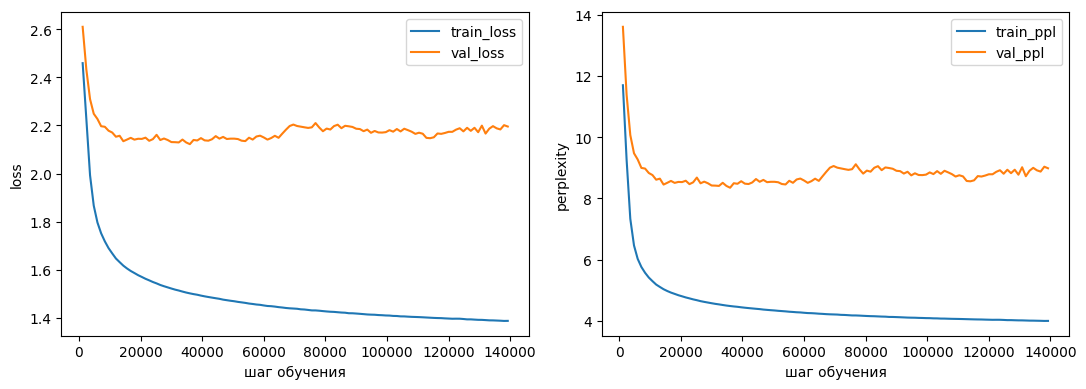

In [9]:
# Графики и контроль после TODO 4
steps = training_trace['step']
train_losses = training_trace['train_loss']
val_losses = training_trace['val_loss']

plt.figure(figsize=(11, 4))
plt.subplot(1, 2, 1)
plt.plot(steps, train_losses, label='train_loss')
plt.plot(steps, val_losses, label='val_loss')
plt.xlabel('шаг обучения')
plt.ylabel('loss')
plt.legend()

plt.subplot(1, 2, 2)
train_ppl = [perplexity_from_loss(v) for v in train_losses]
val_ppl = [perplexity_from_loss(v) for v in val_losses]
plt.plot(steps, train_ppl, label='train_ppl')
plt.plot(steps, val_ppl, label='val_ppl')
plt.xlabel('шаг обучения')
plt.ylabel('perplexity')
plt.legend()
plt.tight_layout()

print(f"Причина остановки    : {training_trace['stop_reason']}")
print(f"Warm-up (мин)        : {training_trace['warmup_minutes']:.2f}")
print(f"Бюджет после warm-up : {training_trace['budget_minutes']:.2f}")
print(f"Измеряемое время (мин): {training_trace['elapsed_minutes']:.2f}")
print(f"Выполнено шагов      : {training_trace['completed_steps']}")
print(f"test_loss            : {test_loss:.4f}")
print(f"test_token_accuracy  : {test_token_accuracy:.4f}")
print(f"test_perplexity      : {test_perplexity:.4f}")
print(f"baseline_perplexity  : {baseline_perplexity:.4f}")
print(f"baseline_pass        : {baseline_pass}")
print(f"cpu_reference_pass   : {cpu_reference_pass}")


## Шаг 5: детерминированная генерация


In [10]:
import json


def ids_to_text(token_ids, id_to_char_map):
    """Преобразует идентификаторы в строку.

    Args:
      token_ids: Последовательность идентификаторов.
      id_to_char_map: Отображение id -> символ.

    Returns:
      Строка символов.

    Raises:
      RuntimeError: Не выбрасывается в штатном режиме.
    """
    return ''.join(id_to_char_map.get(int(token), '') for token in token_ids if int(token) != PAD_ID)


def generate_greedy(model, prompt_ids, steps, context_len):
    """Генерирует продолжение в режиме argmax через свободную автогенерацию.

    Args:
      model: Обученная модель.
      prompt_ids: Начальная последовательность идентификаторов.
      steps: Число новых токенов.
      context_len: Длина модельного контекста.

    Returns:
      Список токенов продолжения длины не больше `steps`.

    Raises:
      ValueError: Если подсказка пуста.
    """
    if len(prompt_ids) == 0:
        raise ValueError('Подсказка не может быть пустой.')

    generated = []
    history = list(prompt_ids)
    for _ in range(steps):
        probs = next_token_distribution(model, history, context_len)
        next_token = int(np.argmax(probs))
        generated.append(next_token)
        history.append(next_token)
    return generated


def build_prompt_targets(encoded_stream, start_indices, context_len, continuation_len, n_prompts):
    """Готовит фиксированные подсказки и эталонные продолжения из test-фрагмента.

    Args:
      encoded_stream: Полный поток кодов корпуса.
      start_indices: Стартовые индексы окон тестовой части.
      context_len: Длина контекста модели.
      continuation_len: Длина целевого продолжения.
      n_prompts: Количество подсказок.

    Returns:
      Список пар `(prompt_ids, target_ids)`.

    Raises:
      ValueError: Если тестовых окон недостаточно.
    """
    valid_starts = [
        int(start) for start in start_indices
        if int(start) + context_len + continuation_len <= len(encoded_stream)
    ]
    if len(valid_starts) < n_prompts:
        raise ValueError('Недостаточно тестовых окон для фиксированного набора подсказок.')

    selected = np.linspace(0, len(valid_starts) - 1, n_prompts, dtype=int)
    pairs = []
    for idx in selected:
        start = valid_starts[int(idx)]
        prompt = encoded_stream[start:start + context_len]
        target = encoded_stream[start + context_len:start + context_len + continuation_len]
        pairs.append((prompt.tolist(), target.tolist()))
    return pairs


fixed_pairs = build_prompt_targets(
    encoded_stream=encoded_ids,
    start_indices=starts_test,
    context_len=cfg['context'],
    continuation_len=CHECK_GEN_STEPS,
    n_prompts=PROMPT_COUNT,
)

success_count = 0
match_ratios = []
examples = []
for pair_idx, (prompt_ids, target_ids) in enumerate(fixed_pairs):
    match_ratio = controlled_match_ratio(
        model,
        prompt_ids,
        target_ids,
        context_len=cfg['context'],
    )
    match_ratios.append(match_ratio)
    if match_ratio >= cfg['gen_match_ratio']:
        success_count += 1

    if pair_idx < 3:
        generated_ids = generate_greedy(model, prompt_ids, CHECK_GEN_STEPS, cfg['context'])
        examples.append((prompt_ids, target_ids, generated_ids))

mean_match_ratio = float(np.mean(match_ratios)) if match_ratios else 0.0
generation_pass = bool(
    success_count >= cfg['gen_threshold']
    and mean_match_ratio >= cfg['gen_mean_threshold']
)

print(
    f'Контролируемых корректных продолжений: {success_count} из {len(fixed_pairs)} '
    f'(порог на подсказку: {cfg["gen_match_ratio"]:.2f})'
)
print(f'Средняя доля совпадений (teacher forcing): {mean_match_ratio:.4f}')
print(f'Жёсткий критерий 19/20 пройден: {success_count >= cfg["gen_threshold"]}')
print(f'Индикатор CPU-ориентира пройден: {cpu_reference_pass}')

for prompt_ids, target_ids, generated_ids in examples:
    print('prompt   :', ids_to_text(prompt_ids[-40:], id_to_char))
    print('expected :', ids_to_text(target_ids, id_to_char))
    print('generated:', ids_to_text(generated_ids, id_to_char))
    print('---')

run_summary = {
    'profile_name': selected_profile_name,
    'stop_reason': training_trace['stop_reason'],
    'warmup_minutes': float(training_trace['warmup_minutes']),
    'timed_elapsed_minutes': float(training_trace['elapsed_minutes']),
    'timed_budget_minutes': float(training_trace['budget_minutes']),
    'completed_steps': int(training_trace['completed_steps']),
    'test_perplexity': float(test_perplexity),
    'baseline_perplexity': float(baseline_perplexity),
    'cpu_reference_perplexity': float(CPU_REFERENCE_PERPLEXITY),
    'baseline_pass': bool(baseline_pass),
    'cpu_reference_pass': bool(cpu_reference_pass),
    'success_count': int(success_count),
    'prompt_count': int(PROMPT_COUNT),
    'mean_match_ratio': float(mean_match_ratio),
    'generation_pass': bool(generation_pass),
    'overall_pass': bool(generation_pass and baseline_pass),
}
print('GPU_RUN_SUMMARY_JSON=' + json.dumps(run_summary, ensure_ascii=False, sort_keys=True))

assert success_count >= cfg['gen_threshold'], 'Порог по числу корректных продолжений (19/20) не достигнут.'
assert mean_match_ratio >= cfg['gen_mean_threshold'], 'Средняя доля совпадений ниже целевого порога.'
assert baseline_pass, 'Модель должна превосходить частотный ориентир по перплексии.'


Контролируемых корректных продолжений: 20 из 20 (порог на подсказку: 0.18)
Средняя доля совпадений (teacher forcing): 0.4156
Жёсткий критерий 19/20 пройден: True
Индикатор CPU-ориентира пройден: False
prompt   : hter and the king's
son and scared my ch
expected : oughs from the c
generated: ildrest the peac
---
prompt   : ourt in these enfoldings?
hath not my ga
expected : it in it the mea
generated: tes the peace th
---
prompt   :  good; which who knows how
that may turn
expected :  back to my adva
generated:  the with his pr
---
GPU_RUN_SUMMARY_JSON={"baseline_pass": true, "baseline_perplexity": 26.929200704052754, "completed_steps": 139200, "cpu_reference_pass": false, "cpu_reference_perplexity": 7.64, "generation_pass": true, "mean_match_ratio": 0.415625, "overall_pass": true, "profile_name": "gpu_60m", "prompt_count": 20, "stop_reason": "early_stopping_val_plateau", "success_count": 20, "test_perplexity": 8.686638837916096, "timed_budget_minutes": 60.0, "timed_elapsed_minutes": 45

## Шаг 6: диагностика внимания


Отношение массы внимания в будущем: 0.00000000


E0000 00:00:1774997146.622205 2795113 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


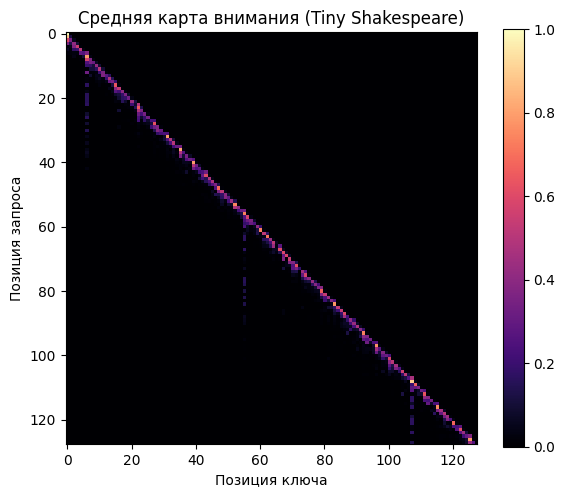

In [11]:
trace_inputs = keras.Input(shape=(cfg['context'],), dtype='int32', name='trace_tokens')
trace_mask = layers.Lambda(lambda t: tf.not_equal(t, PAD_ID), name='trace_mask')(trace_inputs)
trace_embeddings = embedding_layer(trace_inputs)
_, trace_attention_scores = decoder_layer(
    trace_embeddings,
    padding_mask=trace_mask,
    return_attention_scores=True,
)
trace_model = keras.Model(trace_inputs, trace_attention_scores, name='trace_model')

sample_tokens = X_test[:1]
attention_scores = trace_model.predict(sample_tokens, verbose=0)
mean_scores = attention_scores[0].mean(axis=0)
useful_len = cfg['context']
heatmap = mean_scores[:useful_len, :useful_len]

future_mass = float(np.triu(heatmap, k=1).sum())
total_mass = float(heatmap.sum())
future_ratio = future_mass / total_mass if total_mass > 0 else 0.0

print(f'Отношение массы внимания в будущем: {future_ratio:.8f}')
assert future_ratio < 1e-4, 'Обнаружено заметное внимание к будущим позициям.'

plt.figure(figsize=(6, 5))
plt.imshow(heatmap, cmap='magma')
plt.colorbar()
plt.title('Средняя карта внимания (Tiny Shakespeare)')
plt.xlabel('Позиция ключа')
plt.ylabel('Позиция запроса')
plt.tight_layout()


## Проверка завершения (GPU-вариант)

1. `gpu_preflight()` пройден полностью.
2. Выполнен отдельный `warm-up`, и его длительность не входит в измеряемый бюджет.
3. Измеряемый бюджет обучения после warm-up: `60` минут (`cfg['max_training_minutes']`).
4. Жёсткий критерий `19/20` достигается по контролируемому продолжению (teacher forcing).
5. Дополнительно достигнут средний порог `mean_match_ratio` для контролируемого продолжения.
6. `test_perplexity < baseline_perplexity`.
7. `test_perplexity < CPU_REFERENCE_PERPLEXITY` используется как индикатор, а не аварийный барьер.
8. Свободная автогенерация выводится как демонстрационный блок качества.
9. Диагностика внимания показывает отсутствие доступа в будущее.
